<a href="https://colab.research.google.com/github/Juansesalgado/Imputaci-n-de-datos/blob/main/Imputacion_Datos_Faltantes_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import holidays

data = pd.read_excel("datos_reorganizados_PMs (SIN IMPUTAR)1.xlsx")
data['datetime'] = pd.to_datetime(data['datetime'])

datetime_col = data['datetime']
df_numeric = data.drop(columns=['datetime'])

day_of_week = data['datetime'].dt.day_name()
is_weekend = data['datetime'].dt.weekday >= 5
colombian_holidays = holidays.country_holidays('CO')
is_holiday = data['datetime'].isin(colombian_holidays)

day_dummies = pd.get_dummies(day_of_week, prefix='day')

df_model_input = pd.concat([df_numeric, day_dummies, is_weekend, is_holiday], axis=1)
df_model_input.rename(columns={0: 'is_weekend', 1: 'is_holiday'}, inplace=True)
df_model_input['is_weekend'] = is_weekend.astype(int)
df_model_input['is_holiday'] = is_holiday.astype(int)

imp_RF = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=3,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    verbose=1,
    random_state=42
)

imp_RF.fit(df_model_input)
df_imputado_completo = pd.DataFrame(imp_RF.transform(df_model_input), columns=df_model_input.columns)

df_imp_RF = df_imputado_completo[df_numeric.columns]

df_final = pd.concat([datetime_col.reset_index(drop=True), df_imp_RF], axis=1)
df_final['day_of_week'] = day_of_week
df_final['is_weekend'] = is_weekend
df_final['is_holiday'] = is_holiday



[IterativeImputer] Completing matrix with shape (365, 21)
[IterativeImputer] Change: 72.21656601552651, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 39.53582393688458, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 23.95613821768319, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 34.387098233389565, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 21.643910217993632, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 14.552096714232098, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 13.106615216410786, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 10.015356101100927, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 11.884388751011462, scaled tolerance: 0.10647752274 
[IterativeImputer] Change: 15.624669960204187, scaled tolerance: 0.10647752274 
[IterativeImputer] Completing matrix with shape (365, 21)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


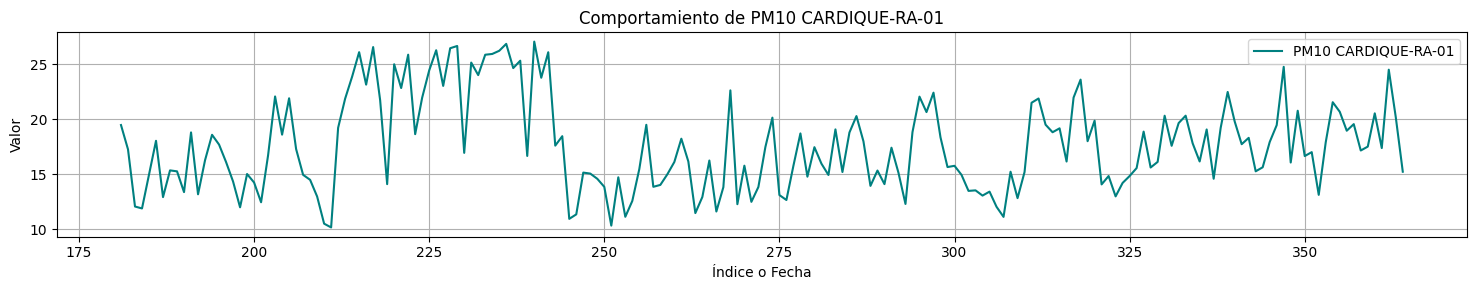

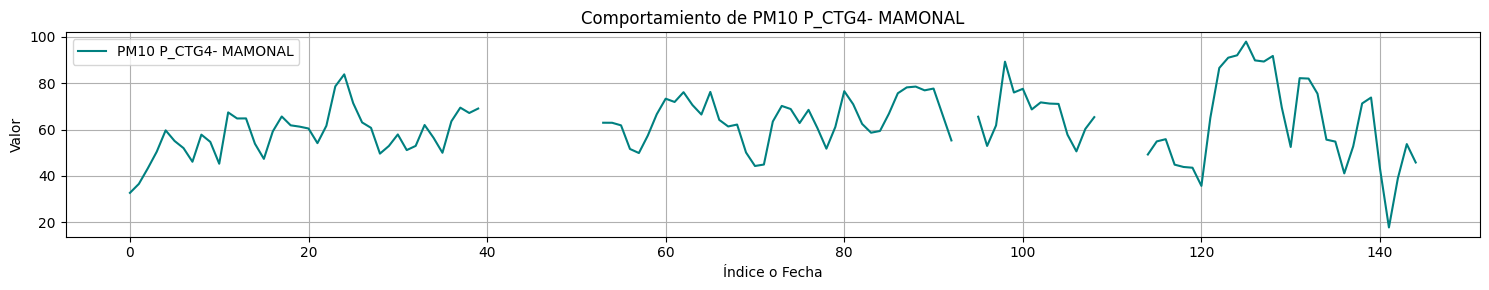

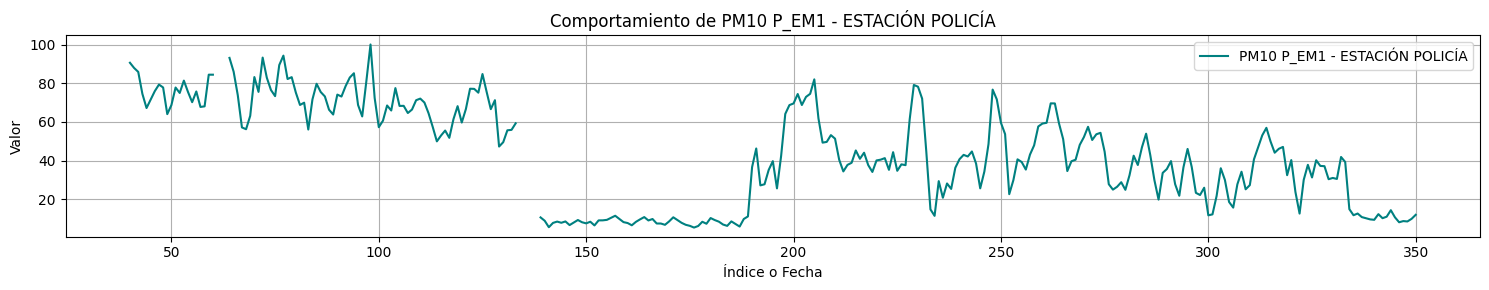

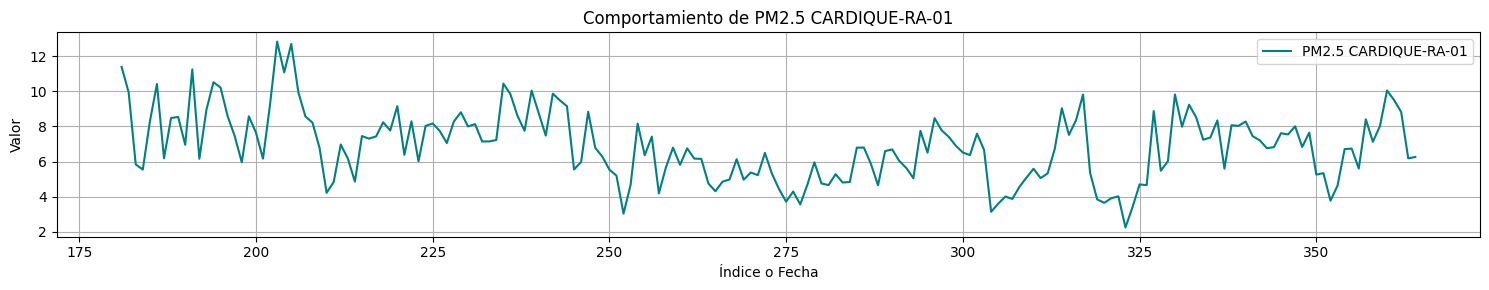

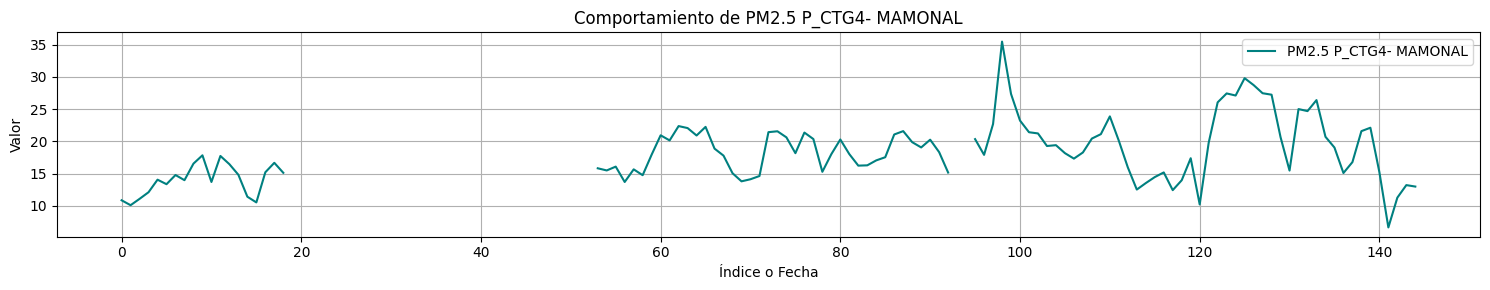

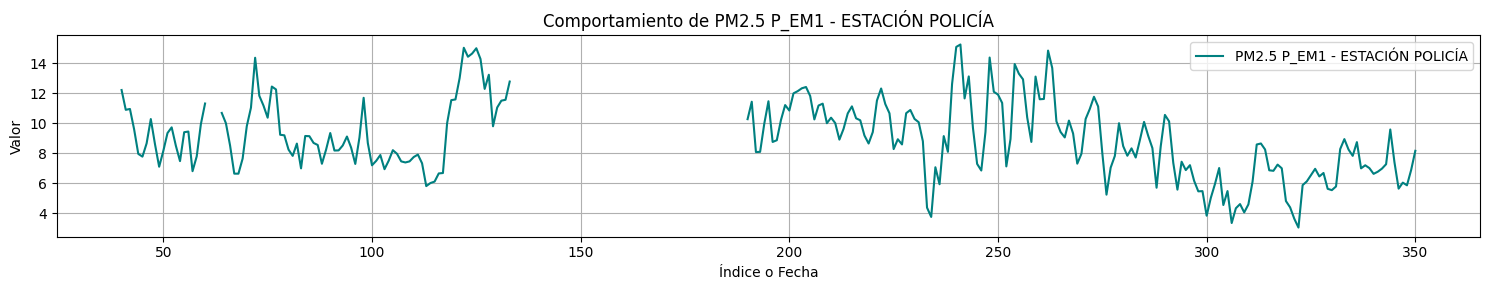

In [11]:
import matplotlib.pyplot as plt

pm_columns = [
    'PM10 CARDIQUE-RA-01',
    'PM10 P_CTG4- MAMONAL',
    'PM10 P_EM1 - ESTACIÓN POLICÍA',
    'PM2.5 CARDIQUE-RA-01',
    'PM2.5 P_CTG4- MAMONAL',
    'PM2.5 P_EM1 - ESTACIÓN POLICÍA'
]

for col in pm_columns:
    plt.figure(figsize=(15, 3))
    plt.plot(data[col], label=col, color='teal')
    plt.title(f'Comportamiento de {col}')
    plt.xlabel('Índice o Fecha')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

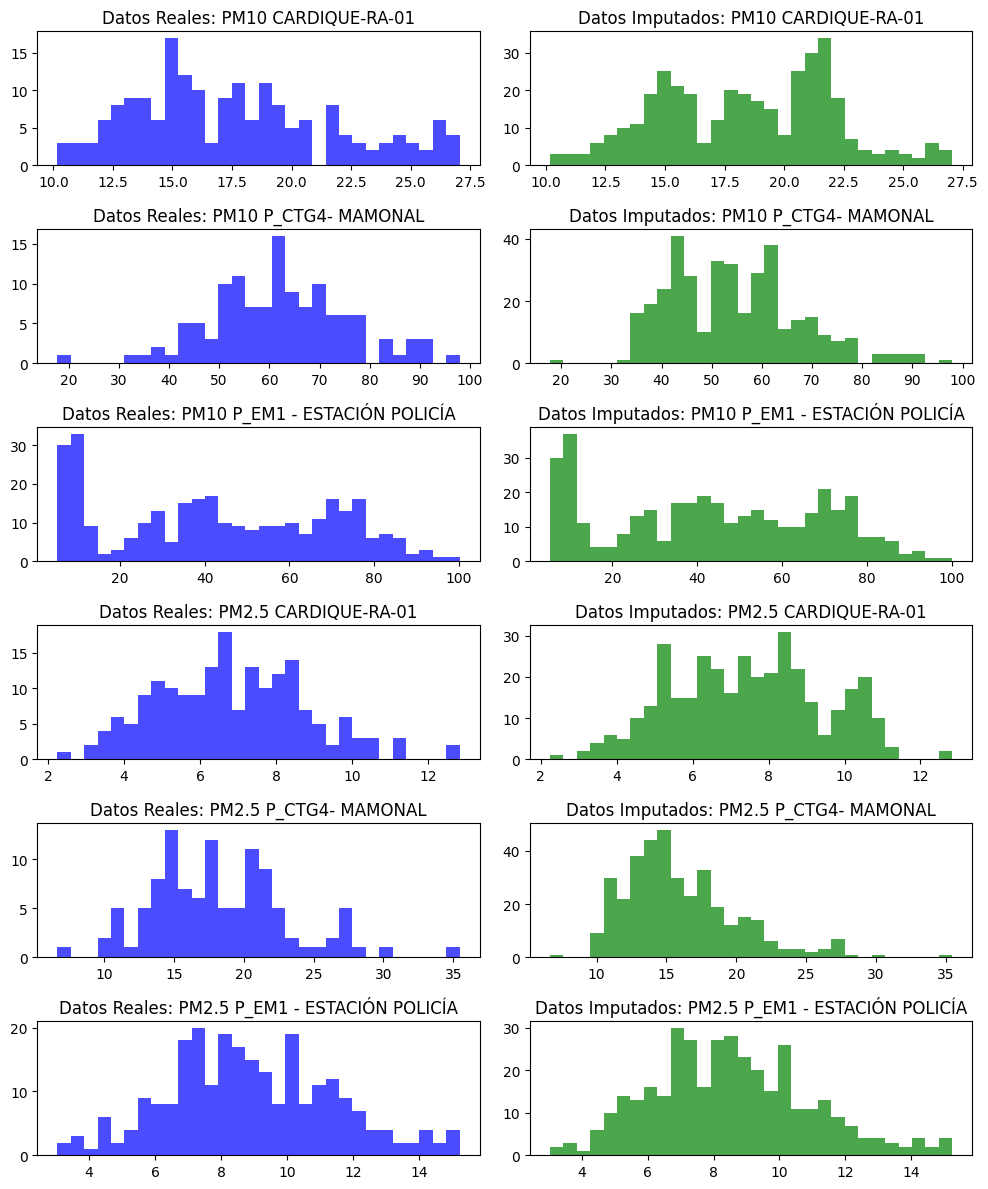

In [10]:
import matplotlib.pyplot as plt


pm_columns = [
    'PM10 CARDIQUE-RA-01',
    'PM10 P_CTG4- MAMONAL', 'PM10 P_EM1 - ESTACIÓN POLICÍA',
    'PM2.5 CARDIQUE-RA-01',
    'PM2.5 P_CTG4- MAMONAL', 'PM2.5 P_EM1 - ESTACIÓN POLICÍA'
]


real_data = data[pm_columns]

imputed_data = df_imp_RF[pm_columns].loc[real_data.index]  # Asegurarnos de tomar solo las filas no nulas

fig, axes = plt.subplots(len(pm_columns), 2, figsize=(10, 2 * len(pm_columns)))

for i, col in enumerate(pm_columns):
    axes[i, 0].hist(real_data[col], bins=30, color='blue', alpha=0.7)
    axes[i, 0].set_title(f'Datos Reales: {col}')

    axes[i, 1].hist(imputed_data[col], bins=30, color='green', alpha=0.7)
    axes[i, 1].set_title(f'Datos Imputados: {col}')

plt.tight_layout()
plt.show()